# thetaFlow Tutorial: Simulating Soil-Water Dynamics

Welcome to the **thetaFlow** tutorial!  This notebook walks you through increasingly realistic simulations of water movement through a soil column, following the Richards equation.

We progress through four levels of complexity:

| Section | What we add | Key concept |
|---------|-------------|-------------|
| 1 | Flat soil column | Infiltration, runoff, drainage |
| 2 | Sloped hillside | Lateral throughflow |
| 3 | Vegetation | Root-zone ET and water uptake |
| 3.5 | X-ray porosity profile | Depth-varying saturated water content from scanner data |
| 4 | Live weather forecast | Real rainfall + PET from Open-Meteo |

---
## Background

**Richards equation** describes the movement of water through an unsaturated porous medium (soil).  Water is driven by two forces:
- **Gravity** – water always wants to move downward.
- **Capillary pressure gradients** – dry soil pulls water towards it (matric suction).

The **van Genuchten** functions relate matric head `h` (m) to volumetric water content θ (m³/m³) and hydraulic conductivity K (m/s).  These three variables form the core of every simulation in thetaFlow.

**Key outputs per timestep:**
- θ profile with depth (how wet is each layer?)
- Infiltration rate (how fast does water enter?)
- Runoff rate (excess rain that can't infiltrate)
- Bottom drainage (water leaving the base)
- Lateral throughflow (on slopes)
- Actual evapotranspiration, AET (with vegetation)

## Setup
Install requirements if needed (only required once).

In [ ]:
# Uncomment if running for the first time:
# %pip install numpy pandas matplotlib

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Import the thetaFlow simulation engine
from simulate_soil_column import (
    SoilProperties,
    ColumnConfig,
    SimulationConfig,
    VegetationType,
    VEGETATION_LIBRARY,
    run_simulation,
    read_forcing,
    _process_forcing_df,
    fetch_openmeteo_forcing,
    read_xray_porosity,
    build_porosity_profile,
)

print('✅ thetaFlow loaded successfully')

✅ thetaFlow loaded successfully


### Helper visualisation functions
These plotting utilities are shared across all four sections.

In [3]:
def plot_water_balance(diagnostics_df, profile_df, title='Soil Column Water Balance', figsize=(14, 9)):
    """Six-panel figure: rain, runoff, lateral flow, AET, mean theta, and theta heatmap."""
    pivot = (
        profile_df
        .pivot(index='depth_m', columns='time_hours', values='theta')
        .sort_index(ascending=True)
    )
    mean_theta = profile_df.groupby('time_hours', as_index=False)['theta'].mean()

    has_lateral = diagnostics_df['lateral_throughflow_mm_h'].abs().max() > 1e-6
    has_aet     = diagnostics_df['aet_mm_h'].abs().max() > 1e-6

    rows = [1, 1]
    if has_lateral: rows.append(1)
    if has_aet:     rows.append(1)
    rows += [1, 4]   # mean theta + heatmap

    fig, axes = plt.subplots(
        nrows=len(rows), ncols=1,
        figsize=figsize, sharex=True,
        constrained_layout=True,
        gridspec_kw={'height_ratios': rows},
    )
    ax_iter = iter(axes)

    t = diagnostics_df['time_hours'].to_numpy(dtype=float)

    # Rain
    ax = next(ax_iter)
    r = diagnostics_df['rainfall_mm_h'].to_numpy(dtype=float)
    ax.step(t, r, where='post', color='#1f77b4', lw=1.8)
    ax.fill_between(t, r, step='post', alpha=0.25, color='#1f77b4')
    ax.set_ylabel('Rain\n(mm/h)', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.25)

    # Runoff
    ax = next(ax_iter)
    ro = diagnostics_df['runoff_mm_h'].to_numpy(dtype=float)
    ax.step(t, ro, where='post', color='#d62728', lw=1.8)
    ax.fill_between(t, ro, step='post', alpha=0.2, color='#d62728')
    ax.set_ylabel('Runoff\n(mm/h)', fontsize=9)
    ax.grid(True, axis='y', alpha=0.25)

    if has_lateral:
        ax = next(ax_iter)
        lat = diagnostics_df['lateral_throughflow_mm_h'].to_numpy(dtype=float)
        ax.plot(t, lat, color='#9467bd', lw=1.8)
        ax.fill_between(t, lat, alpha=0.2, color='#9467bd')
        ax.set_ylabel('Lateral\n(mm/h)', fontsize=9)
        ax.grid(True, axis='y', alpha=0.25)

    if has_aet:
        ax = next(ax_iter)
        aet = diagnostics_df['aet_mm_h'].to_numpy(dtype=float)
        ax.plot(t, aet, color='#e377c2', lw=1.8)
        ax.fill_between(t, aet, alpha=0.2, color='#e377c2')
        ax.set_ylabel('AET\n(mm/h)', fontsize=9)
        ax.grid(True, axis='y', alpha=0.25)

    # Mean theta
    ax = next(ax_iter)
    ax.plot(mean_theta['time_hours'], mean_theta['theta'], color='#2ca02c', lw=1.8)
    ax.set_ylabel('Mean\nθ (–)', fontsize=9)
    ax.grid(True, axis='y', alpha=0.25)

    # Heatmap
    ax = next(ax_iter)
    mesh = ax.pcolormesh(
        pivot.columns.values, pivot.index.values, pivot.values,
        shading='auto', cmap='YlGnBu', vmin=0, vmax=pivot.values.max(),
    )
    ax.invert_yaxis()
    ax.set_xlabel('Time (hours)', fontsize=10)
    ax.set_ylabel('Depth (m)', fontsize=10)
    cbar = plt.colorbar(mesh, ax=ax)
    cbar.set_label('θ (m³/m³)', fontsize=9)
    plt.show()


def plot_profile_snapshots(profile_df, times_h, soil, title='Moisture Profile Snapshots'):
    """Overlay θ–depth profiles at selected simulation times."""
    all_times = profile_df['time_hours'].unique()
    cmap = plt.cm.plasma
    colours = cmap(np.linspace(0.1, 0.9, len(times_h)))

    fig, ax = plt.subplots(figsize=(5, 7))
    for colour, t_h in zip(colours, times_h):
        closest = all_times[np.argmin(np.abs(all_times - t_h))]
        snap = profile_df[profile_df['time_hours'] == closest].sort_values('depth_m')
        ax.plot(snap['theta'], snap['depth_m'], color=colour, lw=2, label=f't = {closest:.1f} h')

    ax.axvline(soil.theta_r, ls='--', color='grey', lw=0.8, label=f'θ_r = {soil.theta_r}')
    ax.axvline(soil.theta_s, ls=':', color='grey', lw=0.8, label=f'θ_s = {soil.theta_s}')
    ax.invert_yaxis()
    ax.set_xlabel('Volumetric water content θ (m³/m³)')
    ax.set_ylabel('Depth (m)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_and_collect(
    soil, column, sim, forcing_df,
    output_subdir='_tmp', vegetation=None,
):
    """Run the simulation and return (profile_df, diagnostics_df) directly."""
    out = Path('outputs') / output_subdir
    run_simulation(soil, column, sim, forcing_df.copy(), out, vegetation=vegetation)
    profile_df     = pd.read_csv(out / 'soil_moisture_profiles.csv')
    diagnostics_df = pd.read_csv(out / 'water_balance_diagnostics.csv')
    return profile_df, diagnostics_df


print('✅ Helper functions defined')

✅ Helper functions defined


---
# Section 1: Flat Soil Column

We start with the simplest possible scenario: a **1D vertical soil column** with no slope, no vegetation, and a prescribed hourly rainfall forcing.

### What we expect to see
- During heavy rain, infiltration is high and runoff is low.
- As the soil saturates, infiltration capacity drops (Green–Ampt) and runoff rises.
- After rain stops, the wetting front continues to migrate downward by gravity.
- Moisture content in upper layers dries out slowly via surface evaporation.

In [4]:
# ── Soil: sandy loam (van Genuchten parameters) ──────────────────────────────
soil = SoilProperties(
    theta_r=0.065,      # residual water content (m³/m³)
    theta_s=0.41,       # saturated water content / porosity (m³/m³)
    alpha_per_m=3.6,    # van Genuchten α (1/m) – controls air-entry pressure
    n=1.56,             # van Genuchten n – controls pore-size distribution
    ks_m_per_s=1.5e-5,  # saturated hydraulic conductivity (m/s) ≈ 54 mm/h
    pore_connectivity=0.5,
)

# ── Column geometry ───────────────────────────────────────────────────────────
column = ColumnConfig(
    nz=100,    # 100 layers
    dz_m=0.01, # each layer 1 cm thick → total depth 1 m
)

# ── Simulation settings ───────────────────────────────────────────────────────
sim_flat = SimulationConfig(
    initial_head_m=-1.0,         # moderately dry initial conditions
    default_dt_hours=1.0,
    max_substep_seconds=60.0,
    min_theta_buffer=0.002,
    slope_angle_deg=0.0,         # ← FLAT: no lateral flow
    hillslope_flow_path_m=1.0,
)

print('Soil properties:')
print(f'  θ_r = {soil.theta_r:.3f}  (residual, "wilting point" approx.)')
print(f'  θ_s = {soil.theta_s:.3f}  (saturated = porosity)')
print(f'  K_s = {soil.ks_m_per_s*1000*3600:.1f} mm/h  (saturated conductivity)')
print(f'  Column depth = {column.nz * column.dz_m:.1f} m  ({column.nz} layers × {column.dz_m*100:.0f} cm)')

Soil properties:
  θ_r = 0.065  (residual, "wilting point" approx.)
  θ_s = 0.410  (saturated = porosity)
  K_s = 54.0 mm/h  (saturated conductivity)
  Column depth = 1.0 m  (100 layers × 1 cm)


Forcing period: 2026-06-01 00:00:00  →  2026-06-04 23:00:00
Number of hourly steps: 96
Total rainfall: 64.8 mm


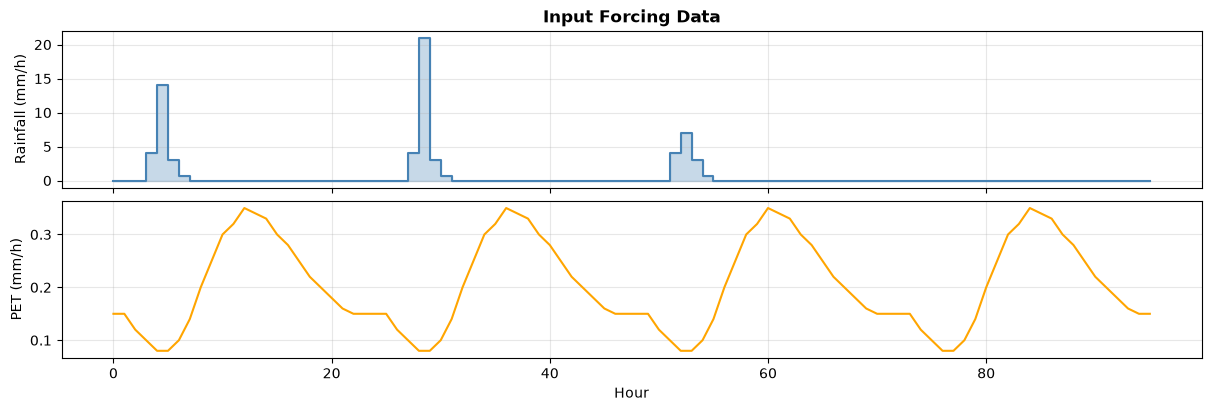

In [5]:
# Load the example forcing CSV (comes with thetaFlow)
forcing_raw = pd.read_csv('forcing_example.csv')
forcing_flat = _process_forcing_df(forcing_raw.copy(), sim_flat.default_dt_hours, source_name='forcing_example.csv')

print(f'Forcing period: {forcing_raw["timestamp"].iloc[0]}  →  {forcing_raw["timestamp"].iloc[-1]}')
print(f'Number of hourly steps: {len(forcing_flat)}')
print(f'Total rainfall: {forcing_raw["rainfall_mm_h"].sum():.1f} mm')

# Quick preview
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4), sharex=True, constrained_layout=True)
ax1.step(range(len(forcing_raw)), forcing_raw['rainfall_mm_h'], where='post', color='steelblue')
ax1.fill_between(range(len(forcing_raw)), forcing_raw['rainfall_mm_h'], step='post', alpha=0.3, color='steelblue')
ax1.set_ylabel('Rainfall (mm/h)')
ax1.set_title('Input Forcing Data', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax2.plot(range(len(forcing_raw)), forcing_raw['pet_mm_h'], color='orange')
ax2.set_ylabel('PET (mm/h)')
ax2.set_xlabel('Hour')
ax2.grid(True, alpha=0.3)
plt.show()

In [6]:
# ── Run simulation ────────────────────────────────────────────────────────────
print('Running flat soil column simulation…')
profile_flat, diag_flat = run_and_collect(soil, column, sim_flat, forcing_flat, output_subdir='sec1_flat')
print(f'Done.  {len(diag_flat)} timesteps recorded.')

Running flat soil column simulation…
Wrote profile output: outputs/sec1_flat/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec1_flat/water_balance_diagnostics.csv
Wrote visualization: outputs/sec1_flat/moisture_heatmap.png
Done.  96 timesteps recorded.


In [7]:
# ── Water balance summary ─────────────────────────────────────────────────────
total_rain   = diag_flat['rainfall_mm_h'].sum()
total_runoff = diag_flat['runoff_mm_h'].sum()
total_drain  = diag_flat['bottom_drainage_mm_h'].sum()
total_aet    = diag_flat['aet_mm_h'].sum()
total_infil  = diag_flat['infiltration_mm_h'].sum()

print('──── Water Balance (Section 1: Flat Column) ────')
print(f'  Total rainfall:    {total_rain:8.2f} mm')
print(f'  Total infiltration:{total_infil:8.2f} mm')
print(f'  Total runoff:      {total_runoff:8.2f} mm')
print(f'  Total AET:         {total_aet:8.2f} mm')
print(f'  Bottom drainage:   {total_drain:8.2f} mm')
print(f'  Runoff coefficient:{total_runoff/max(total_rain,1e-9):.1%}')

──── Water Balance (Section 1: Flat Column) ────
  Total rainfall:       64.80 mm
  Total infiltration:   64.80 mm
  Total runoff:          0.00 mm
  Total AET:            19.60 mm
  Bottom drainage:      16.81 mm
  Runoff coefficient:0.0%


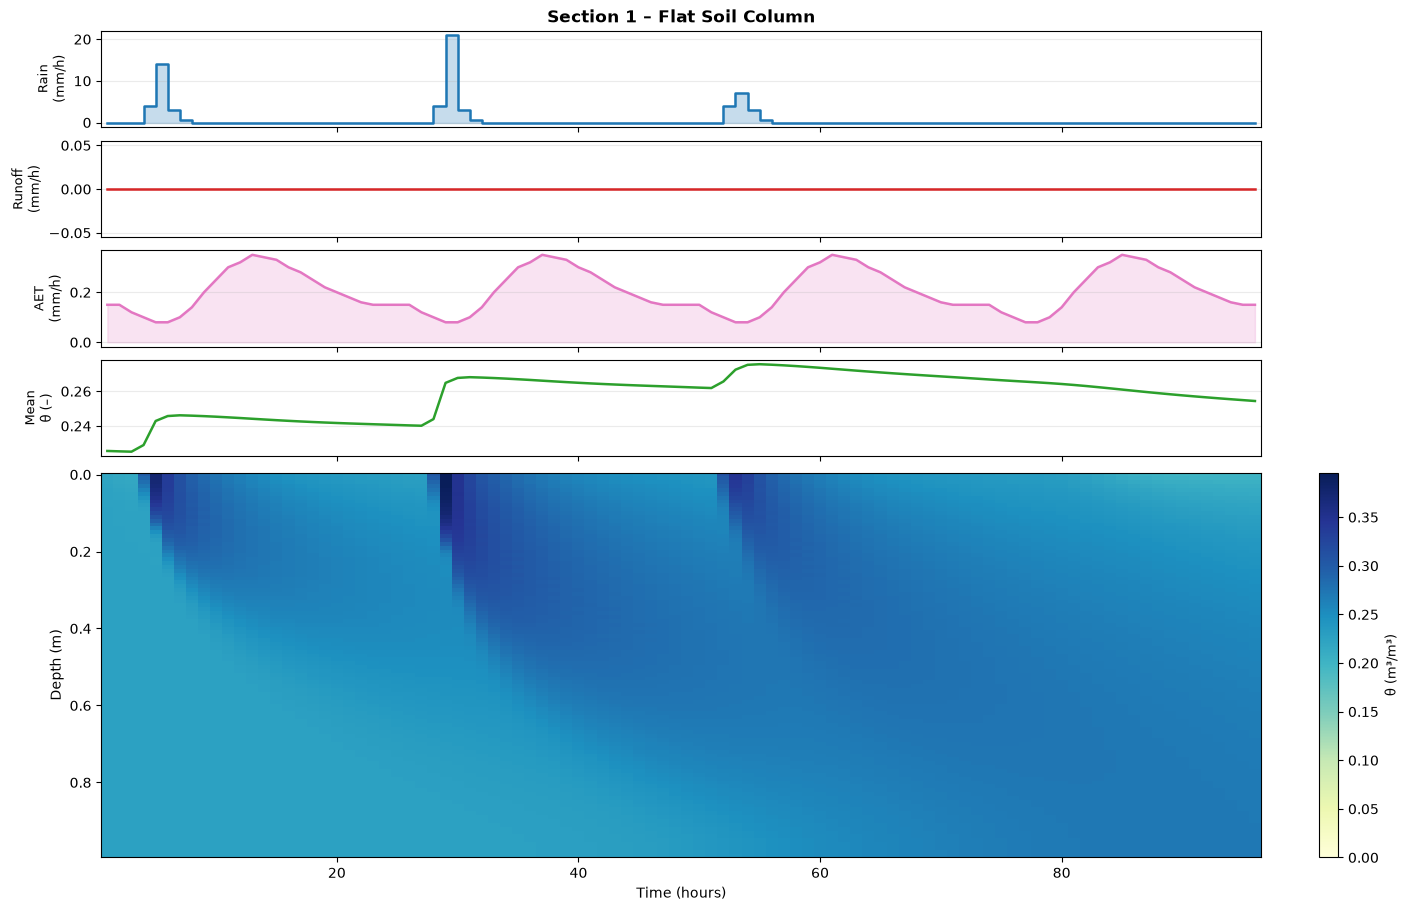

In [8]:
# ── Full water balance visualisation ─────────────────────────────────────────
plot_water_balance(diag_flat, profile_flat, title='Section 1 – Flat Soil Column')

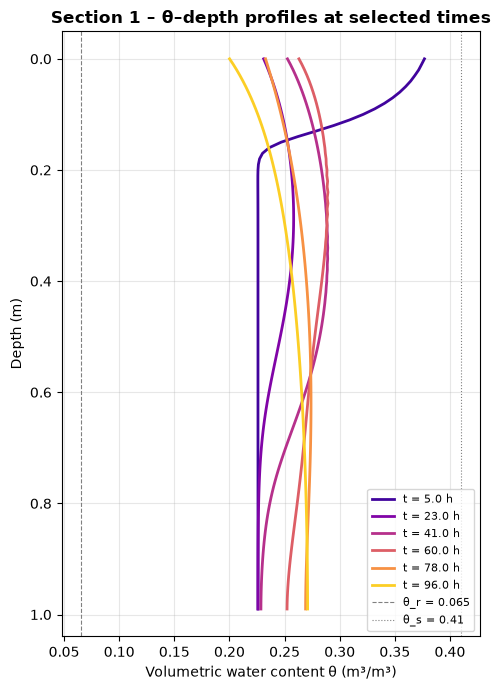

💡 Notice the wetting front descending over time.
   The upper layers dry out between rain events via surface evaporation.


In [9]:
# ── Profile snapshots: watch the wetting front move down ─────────────────────
n_hours = diag_flat['time_hours'].max()
snap_times = np.linspace(n_hours * 0.05, n_hours, 6)
plot_profile_snapshots(
    profile_flat, snap_times, soil,
    title='Section 1 – θ–depth profiles at selected times'
)
print('💡 Notice the wetting front descending over time.')
print('   The upper layers dry out between rain events via surface evaporation.')

---
# Section 2: Adding Hillslope Lateral Flow

Real landscapes are rarely flat.  On a hillslope, saturated or near-saturated soil generates **lateral throughflow** – water moving downslope through the soil rather than running off at the surface.  This is a critical process in catchment hydrology.

### How thetaFlow models lateral flow
Each layer contributes a lateral drainage flux proportional to:
- The layer's hydraulic conductivity K
- The sine of the slope angle (gravity component along slope)
- Divided by the hillslope length (flow path)

A steeper or shorter slope = more lateral drainage = drier soil at steady state.

### What to look for
- The **Lateral (mm/h)** panel appears with non-zero values.
- Mean θ stays **lower** than in the flat case (lateral drainage removes water).
- Surface runoff may be **reduced** as lateral drainage competes.

In [10]:
# ── Three slope scenarios ─────────────────────────────────────────────────────
slope_scenarios = [
    ('Flat (0°)',      0.0,  100.0),
    ('Gentle (3°)',    3.0,  50.0),
    ('Moderate (6°)',  6.0,  50.0),
    ('Steep (15°)',   15.0,  20.0),
]

results_slope = {}
for label, angle, flow_path in slope_scenarios:
    sim_s = SimulationConfig(
        initial_head_m=-1.0,
        default_dt_hours=1.0,
        max_substep_seconds=60.0,
        min_theta_buffer=0.002,
        slope_angle_deg=angle,
        hillslope_flow_path_m=flow_path,
    )
    subdir = f'sec2_slope_{int(angle)}deg'
    prof, diag = run_and_collect(soil, column, sim_s, forcing_flat, output_subdir=subdir)
    results_slope[label] = (prof, diag)
    print(f'  {label:20s}  mean θ = {prof["theta"].mean():.4f}  total lateral = {diag["lateral_throughflow_mm_h"].sum():.1f} mm')

Wrote profile output: outputs/sec2_slope_0deg/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec2_slope_0deg/water_balance_diagnostics.csv
Wrote visualization: outputs/sec2_slope_0deg/moisture_heatmap.png
  Flat (0°)             mean θ = 0.2584  total lateral = 0.0 mm
Wrote profile output: outputs/sec2_slope_3deg/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec2_slope_3deg/water_balance_diagnostics.csv
Wrote visualization: outputs/sec2_slope_3deg/moisture_heatmap.png
  Gentle (3°)           mean θ = 0.2583  total lateral = 0.0 mm
Wrote profile output: outputs/sec2_slope_6deg/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec2_slope_6deg/water_balance_diagnostics.csv
Wrote visualization: outputs/sec2_slope_6deg/moisture_heatmap.png
  Moderate (6°)         mean θ = 0.2583  total lateral = 0.1 mm
Wrote profile output: outputs/sec2_slope_15deg/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec2_slope_15deg/water_balance_diagnostics.

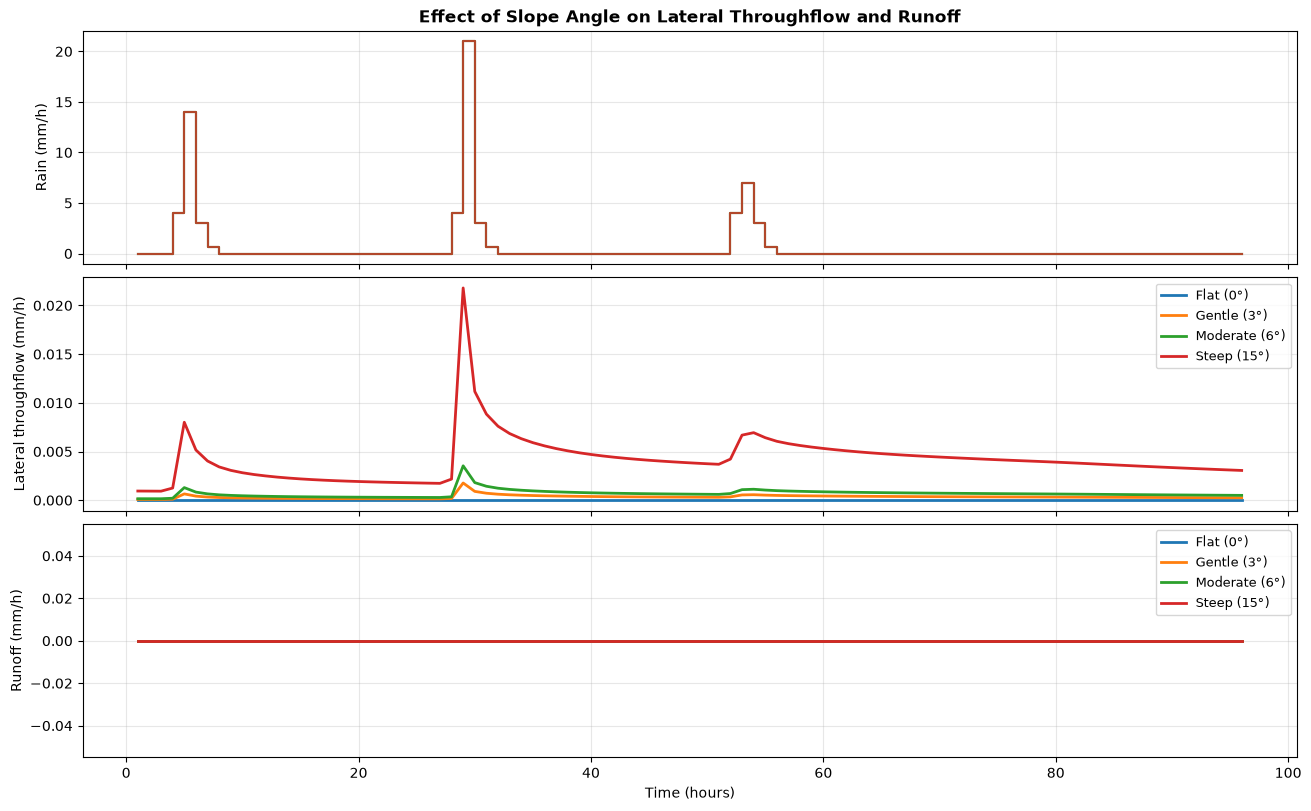

In [11]:
# ── Compare lateral throughflow across slopes ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (label, _angle, _fp), colour in zip(slope_scenarios, colours):
    prof, diag = results_slope[label]
    t = diag['time_hours'].to_numpy(float)
    axes[0].step(t, diag['rainfall_mm_h'], where='post', color=colour, alpha=0.7, lw=1.5)
    axes[1].plot(t, diag['lateral_throughflow_mm_h'], color=colour, lw=2, label=label)
    axes[2].plot(t, diag['runoff_mm_h'], color=colour, lw=2, label=label)

axes[0].set_ylabel('Rain (mm/h)')
axes[0].set_title('Effect of Slope Angle on Lateral Throughflow and Runoff', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel('Lateral throughflow (mm/h)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[2].set_ylabel('Runoff (mm/h)')
axes[2].set_xlabel('Time (hours)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
plt.show()

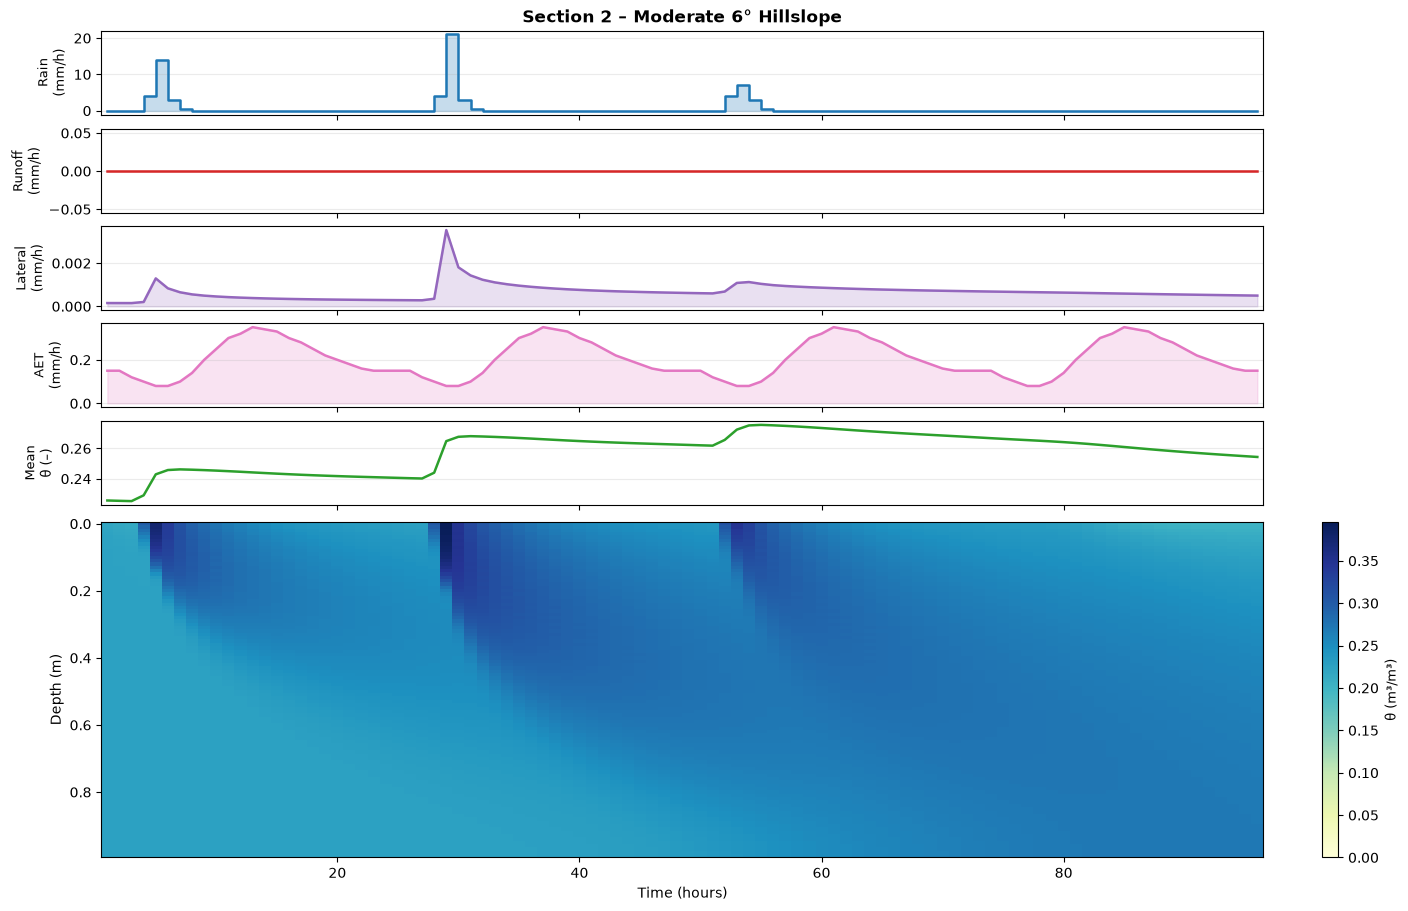

In [12]:
# ── Full dashboard for the 6° moderate slope ─────────────────────────────────
prof_6, diag_6 = results_slope['Moderate (6°)']
plot_water_balance(diag_6, prof_6, title='Section 2 – Moderate 6° Hillslope')

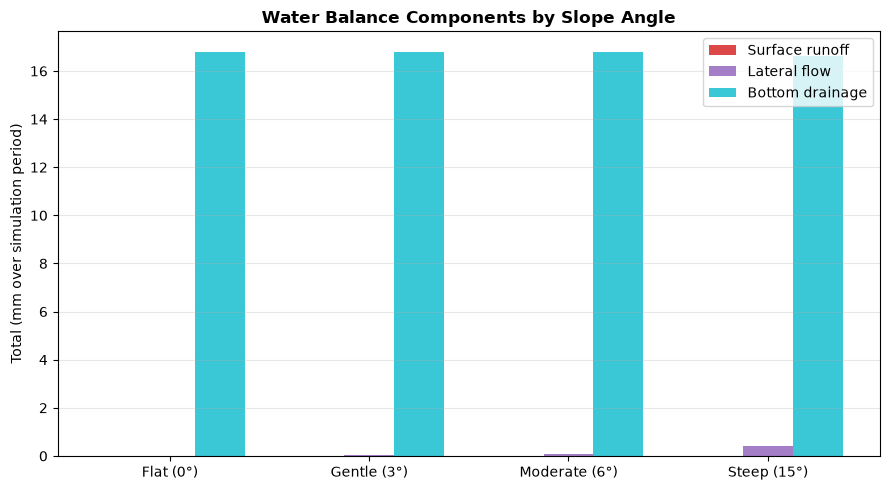

💡 Steeper slopes route more water as lateral subsurface flow and less as surface runoff.


In [13]:
# ── Bar chart: water balance components by slope ──────────────────────────────
labels  = [s[0] for s in slope_scenarios]
runoffs  = [results_slope[l][1]['runoff_mm_h'].sum()              for l in labels]
laterals = [results_slope[l][1]['lateral_throughflow_mm_h'].sum() for l in labels]
drains   = [results_slope[l][1]['bottom_drainage_mm_h'].sum()     for l in labels]

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, runoffs,  width, label='Surface runoff',   color='#d62728', alpha=0.85)
ax.bar(x,         laterals, width, label='Lateral flow',     color='#9467bd', alpha=0.85)
ax.bar(x + width, drains,   width, label='Bottom drainage',  color='#17becf', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Total (mm over simulation period)')
ax.set_title('Water Balance Components by Slope Angle', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 Steeper slopes route more water as lateral subsurface flow and less as surface runoff.')

---
# Section 3: Adding Vegetation

Plants intercept and transpire water through their roots — a process called **evapotranspiration (ET)**.  This can be the dominant water loss term in many climates.

thetaFlow models vegetation through three parameters:
- `rooting_depth_m` – depth to which roots extract water
- `pet_scale` – ratio of this vegetation's ET demand to a reference crop (Penman–Monteith grass)

Water uptake is distributed across the root zone in proportion to the available water in each layer (stress-weighted approach).  When soil moisture falls below the buffer threshold, uptake in that layer stops.

### What to look for
- The **AET** panel lights up — actual evapotranspiration from the root zone.
- Moisture is removed from **depth** (not just the surface layer as in no-vegetation runs).
- Deep-rooted vegetation (woodland) extracts water from deeper layers.
- High-demand crops dry soil faster between rain events.

In [14]:
# ── Available vegetation types ─────────────────────────────────────────────────
print(f"{'Name':<25} {'Root depth (m)':>14} {'PET scale':>10}  Description")
print('─' * 80)
for name, veg in sorted(VEGETATION_LIBRARY.items()):
    print(f'{name:<25} {veg.rooting_depth_m:>14.2f} {veg.pet_scale:>10.2f}  {veg.description}')

Name                      Root depth (m)  PET scale  Description
────────────────────────────────────────────────────────────────────────────────
bare_soil                           0.00       0.30  No vegetation; evaporation from soil surface only.
broadleaf_woodland                  1.50       1.10  Deciduous broadleaf trees (oak, ash, beech, etc.).
coniferous_woodland                 1.20       1.05  Evergreen coniferous plantation or native forest.
grass                               0.30       1.00  Short managed or natural grass sward.
maize                               1.20       1.15  Silage or grain maize.
moorland                            0.20       0.70  Upland heath and blanket bog dominated by heather and sedge.
oilseed_rape                        0.90       1.00  Winter oilseed rape (canola).
potato                              0.60       1.05  Potato tuber crop.
sugar_beet                          1.00       1.00  Sugar beet root crop.
urban                           

In [15]:
# ── Compare vegetation types on the 6° slope ──────────────────────────────────
veg_scenarios = ['bare_soil', 'grass', 'wheat', 'broadleaf_woodland']

sim_veg = SimulationConfig(
    initial_head_m=-1.0,
    default_dt_hours=1.0,
    max_substep_seconds=60.0,
    min_theta_buffer=0.002,
    slope_angle_deg=6.0,
    hillslope_flow_path_m=50.0,
)

results_veg = {}
for vname in veg_scenarios:
    veg = VEGETATION_LIBRARY[vname]
    prof, diag = run_and_collect(
        soil, column, sim_veg, forcing_flat,
        output_subdir=f'sec3_veg_{vname}', vegetation=veg,
    )
    results_veg[vname] = (prof, diag, veg)
    total_aet = diag['aet_mm_h'].sum()
    total_ro  = diag['runoff_mm_h'].sum()
    mean_t    = prof['theta'].mean()
    print(f'  {vname:<22}  AET = {total_aet:5.1f} mm   runoff = {total_ro:5.1f} mm   mean θ = {mean_t:.4f}')

Vegetation: bare_soil (rooting depth 0.00 m, PET scale 0.30)
Wrote profile output: outputs/sec3_veg_bare_soil/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec3_veg_bare_soil/water_balance_diagnostics.csv
Wrote visualization: outputs/sec3_veg_bare_soil/moisture_heatmap.png
  bare_soil               AET =  19.6 mm   runoff =   0.0 mm   mean θ = 0.2583
Vegetation: grass (rooting depth 0.30 m, PET scale 1.00)
Wrote profile output: outputs/sec3_veg_grass/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec3_veg_grass/water_balance_diagnostics.csv
Wrote visualization: outputs/sec3_veg_grass/moisture_heatmap.png
  grass                   AET =  19.6 mm   runoff =   0.0 mm   mean θ = 0.2585
Vegetation: wheat (rooting depth 1.00 m, PET scale 1.00)
Wrote profile output: outputs/sec3_veg_wheat/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec3_veg_wheat/water_balance_diagnostics.csv
Wrote visualization: outputs/sec3_veg_wheat/moisture_heatmap.png
  wheat

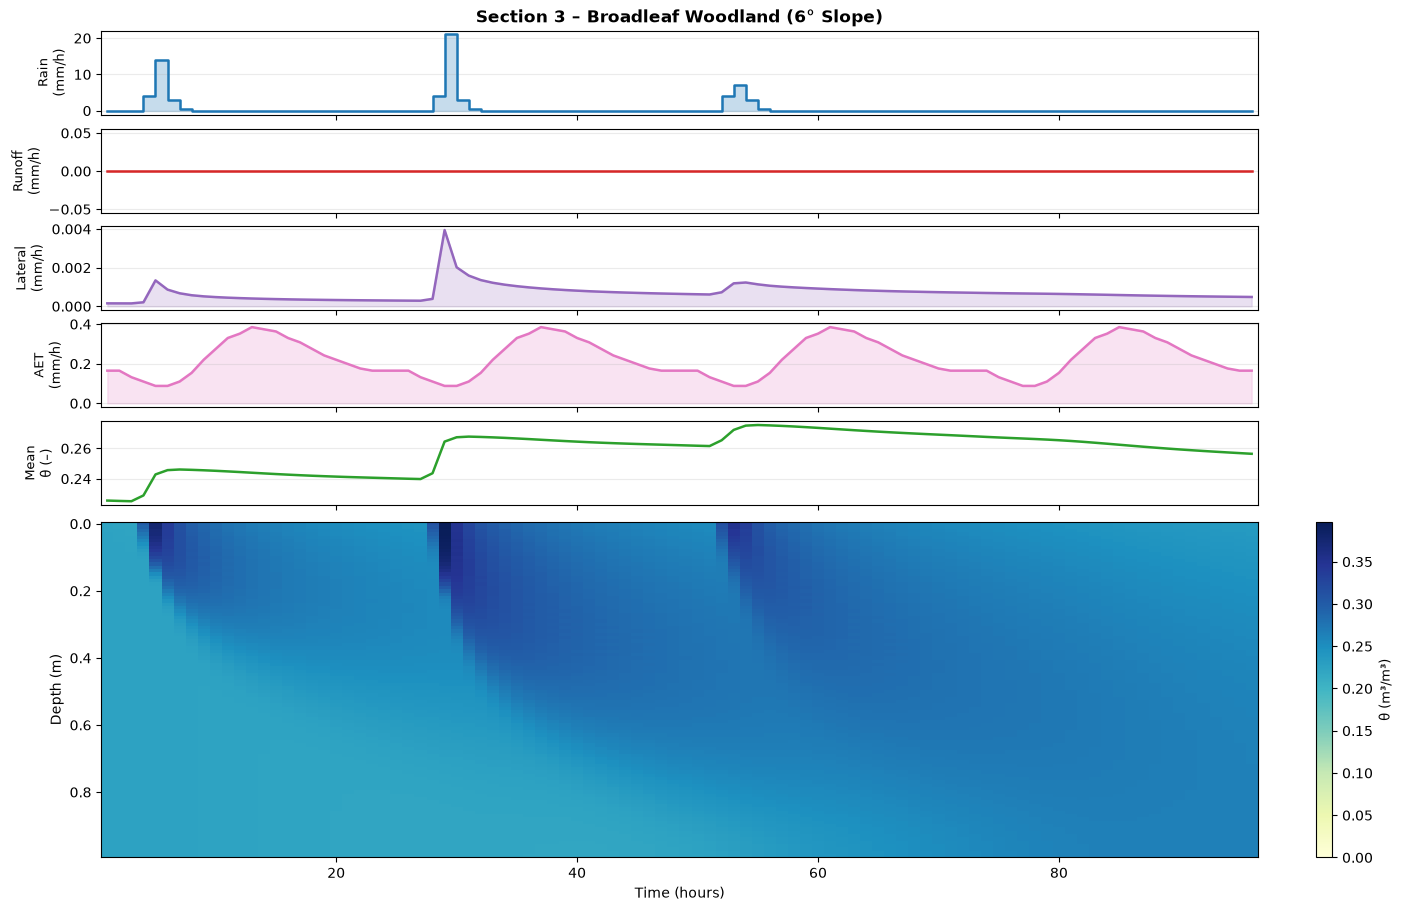

In [16]:
# ── Full dashboard for broadleaf woodland ─────────────────────────────────────
prof_wood, diag_wood, _ = results_veg['broadleaf_woodland']
plot_water_balance(diag_wood, prof_wood, title='Section 3 – Broadleaf Woodland (6° Slope)')

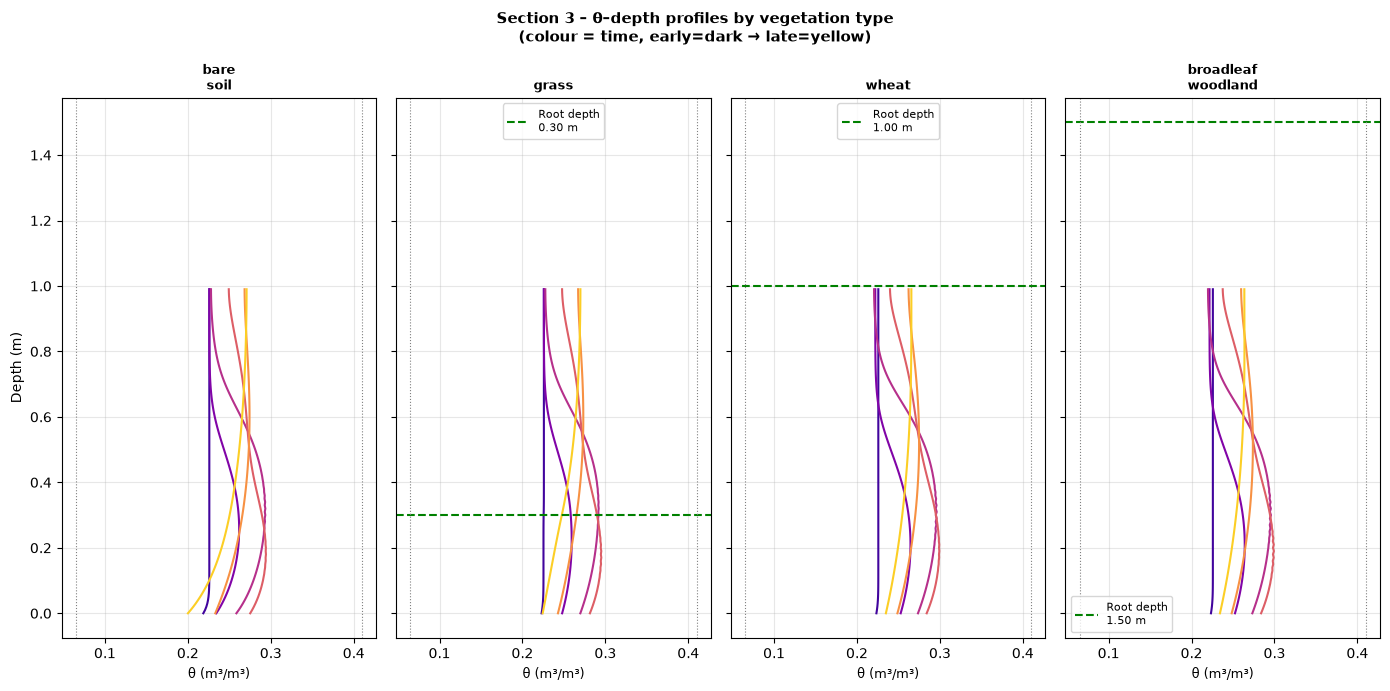

💡 Woodland extracts water from deep in the profile; bare soil only from the surface.


In [17]:
# ── Compare θ–depth profiles: where does each vegetation type extract water? ──
fig, axes = plt.subplots(1, len(veg_scenarios), figsize=(14, 7), sharey=True)
cmap = plt.cm.plasma

for ax, vname in zip(axes, veg_scenarios):
    prof, diag, veg = results_veg[vname]
    all_times = prof['time_hours'].unique()
    snap_times = np.linspace(all_times.min(), all_times.max(), 6)
    colours = cmap(np.linspace(0.1, 0.9, len(snap_times)))

    for col, t_h in zip(colours, snap_times):
        closest = all_times[np.argmin(np.abs(all_times - t_h))]
        snap = prof[prof['time_hours'] == closest].sort_values('depth_m')
        ax.plot(snap['theta'], snap['depth_m'], color=col, lw=1.5)

    if veg.rooting_depth_m > 0:
        ax.axhline(veg.rooting_depth_m, ls='--', color='green', lw=1.5,
                   label=f'Root depth\n{veg.rooting_depth_m:.2f} m')
        ax.legend(fontsize=8)

    ax.axvline(soil.theta_r, ls=':', color='grey', lw=0.8)
    ax.axvline(soil.theta_s, ls=':', color='grey', lw=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('θ (m³/m³)', fontsize=9)
    ax.set_title(vname.replace('_', '\n'), fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Depth (m)')
fig.suptitle('Section 3 – θ–depth profiles by vegetation type\n(colour = time, early=dark → late=yellow)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Woodland extracts water from deep in the profile; bare soil only from the surface.')

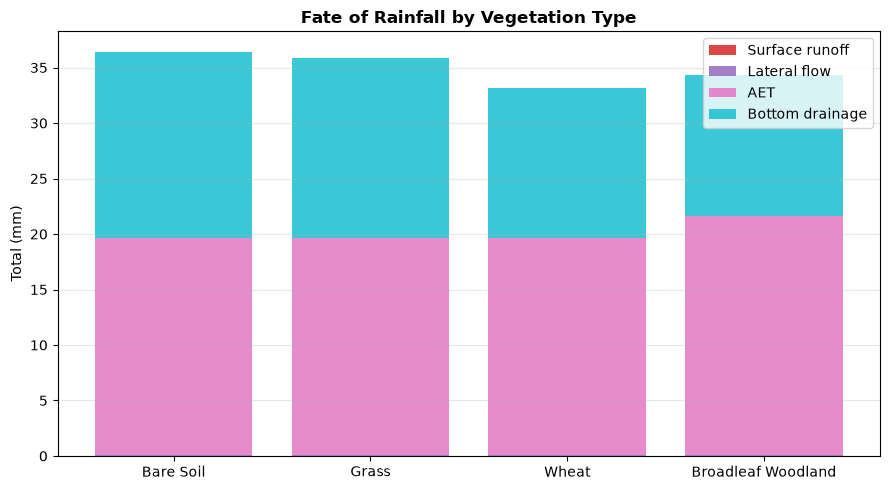

In [18]:
# ── Stacked bar: fate of rainfall by vegetation type ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
veg_labels = [v.replace('_', ' ').title() for v in veg_scenarios]

runoffs  = [results_veg[v][1]['runoff_mm_h'].sum()              for v in veg_scenarios]
laterals = [results_veg[v][1]['lateral_throughflow_mm_h'].sum() for v in veg_scenarios]
aets     = [results_veg[v][1]['aet_mm_h'].sum()                 for v in veg_scenarios]
drains   = [results_veg[v][1]['bottom_drainage_mm_h'].sum()     for v in veg_scenarios]

x = np.arange(len(veg_labels))
ax.bar(x, runoffs,  label='Surface runoff',  color='#d62728', alpha=0.85)
ax.bar(x, laterals, bottom=runoffs, label='Lateral flow', color='#9467bd', alpha=0.85)
ax.bar(x, aets,     bottom=np.add(runoffs, laterals), label='AET', color='#e377c2', alpha=0.85)
ax.bar(x, drains,   bottom=np.add(np.add(runoffs, laterals), aets), label='Bottom drainage', color='#17becf', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(veg_labels, fontsize=10)
ax.set_ylabel('Total (mm)')
ax.set_title('Fate of Rainfall by Vegetation Type', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
# Section 3.5: X-ray Scanner Porosity Profile

Real soil cores are not uniform — porosity (and therefore saturated water content θ_s) varies with depth due to compaction, root channels, bioturbation, and sediment layering.  An X-ray scanner can measure bulk density and derive total porosity at millimetre resolution down the core.

thetaFlow can read this depth–porosity profile and use it to **replace the uniform θ_s** in the soil config with a per-layer value, letting the physics accurately reflect the measured pore structure.

### What you need
A CSV file (e.g. from a CT scanner) with two columns:
-  — depth below the surface in metres
-  — total porosity at that depth (0–1)

Additional columns are ignored.  An example file () is included with thetaFlow.


In [19]:
# ── Load and inspect an X-ray porosity profile ────────────────────────────────
porosity_df = read_xray_porosity(Path('xray_porosity_example.csv'))
print(porosity_df.head(10).to_string(index=False))


Read 30 depth–porosity measurements from 'xray_porosity_example.csv' (depth range 0.000–1.000 m, porosity range 0.300–0.440).
 depth_m  porosity
    0.00      0.44
    0.02      0.43
    0.04      0.42
    0.06      0.41
    0.08      0.40
    0.10      0.39
    0.12      0.38
    0.14      0.37
    0.16      0.36
    0.18      0.35


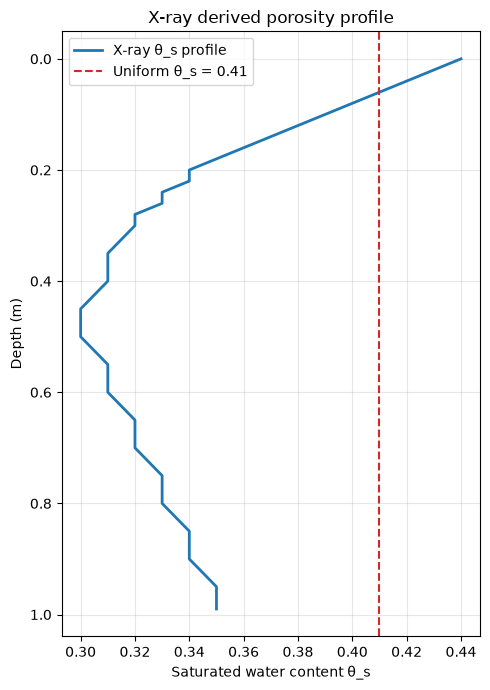

In [20]:
# ── Visualise the porosity profile vs the uniform soil value ─────────────────
soil_base = SoilProperties(
    theta_r=0.065, theta_s=0.41, alpha_per_m=3.6, n=1.56,
    ks_m_per_s=1.5e-5, pore_connectivity=0.5
)
column_xray = ColumnConfig(nz=100, dz_m=0.01)
sim_xray = SimulationConfig(
    initial_head_m=-1.0, default_dt_hours=1.0,
    max_substep_seconds=60.0, min_theta_buffer=0.002
)

# Interpolate measured porosity onto the 100-layer column grid
from simulate_soil_column import build_column_geometry
_, depth_grid = build_column_geometry(column_xray.nz, column_xray.dz_m)
theta_s_profile = build_porosity_profile(porosity_df, depth_grid, soil_base)

fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(theta_s_profile, depth_grid, color='#1f77b4', linewidth=2, label='X-ray θ_s profile')
ax.axvline(soil_base.theta_s, color='#d62728', linestyle='--', linewidth=1.5,
           label=f'Uniform θ_s = {soil_base.theta_s}')
ax.invert_yaxis()
ax.set_xlabel('Saturated water content θ_s')
ax.set_ylabel('Depth (m)')
ax.set_title('X-ray derived porosity profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# ── Run simulation with and without the X-ray porosity profile ────────────────
forcing_xray = read_forcing(Path('forcing_example.csv'), sim_xray.default_dt_hours)

# Without porosity (uniform theta_s)
prof_uniform, diag_uniform, _ = run_simulation.__wrapped__ if hasattr(run_simulation, '__wrapped__') else (None, None, None)

# We call run_simulation via a helper that returns DataFrames directly
def _run(porosity=None):
    import tempfile, os
    with tempfile.TemporaryDirectory() as tmpdir:
        run_simulation(
            soil_base, column_xray, sim_xray, forcing_xray.copy(),
            Path(tmpdir), porosity_df=porosity
        )
        import pandas as pd
        prof = pd.read_csv(Path(tmpdir) / 'soil_moisture_profiles.csv')
        diag = pd.read_csv(Path(tmpdir) / 'water_balance_diagnostics.csv')
    return prof, diag

print('Running uniform θ_s simulation…')
prof_uniform, diag_uniform = _run(porosity=None)
print('Running X-ray porosity simulation…')
prof_xray, diag_xray = _run(porosity=porosity_df)
print('Done.')


Running uniform θ_s simulation…
Wrote profile output: /var/folders/4q/8sr2sf993fz1hpw5mfscbf600000gn/T/tmpcxn067et/soil_moisture_profiles.csv
Wrote diagnostics output: /var/folders/4q/8sr2sf993fz1hpw5mfscbf600000gn/T/tmpcxn067et/water_balance_diagnostics.csv
Wrote visualization: /var/folders/4q/8sr2sf993fz1hpw5mfscbf600000gn/T/tmpcxn067et/moisture_heatmap.png
Running X-ray porosity simulation…
X-ray porosity profile applied: theta_s range 0.300–0.440 (base soil theta_s = 0.410).
Wrote profile output: /var/folders/4q/8sr2sf993fz1hpw5mfscbf600000gn/T/tmpmtw8zbgg/soil_moisture_profiles.csv
Wrote diagnostics output: /var/folders/4q/8sr2sf993fz1hpw5mfscbf600000gn/T/tmpmtw8zbgg/water_balance_diagnostics.csv
Wrote visualization: /var/folders/4q/8sr2sf993fz1hpw5mfscbf600000gn/T/tmpmtw8zbgg/moisture_heatmap.png
Done.


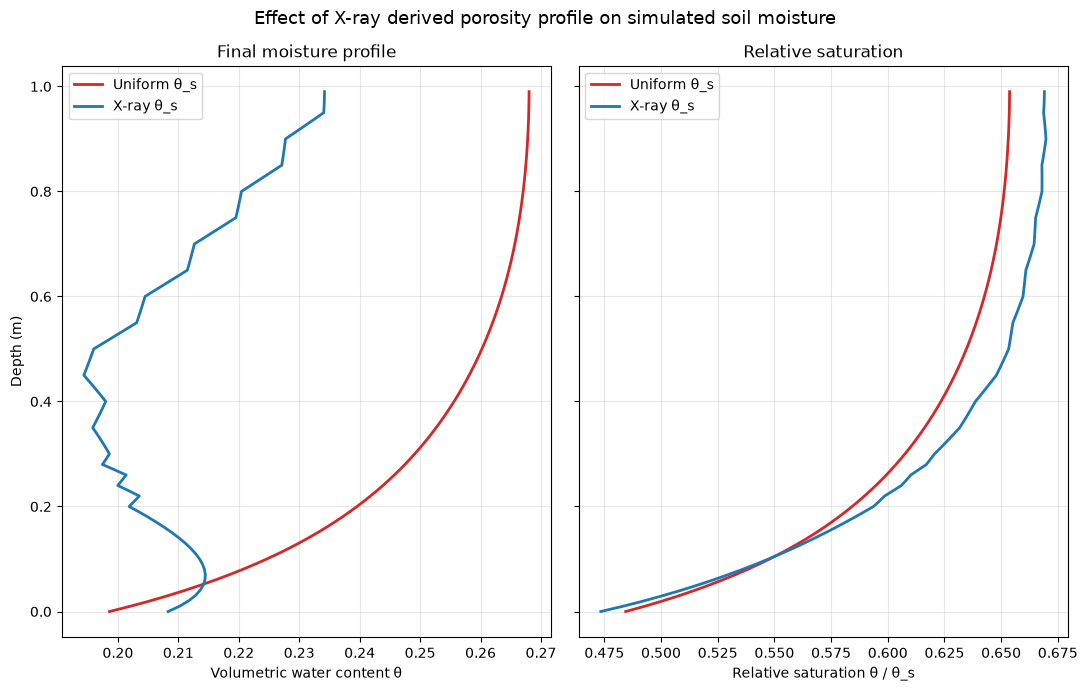

In [22]:
# ── Compare final moisture profiles: uniform vs X-ray θ_s ────────────────────
last_step_uniform = prof_uniform[prof_uniform['step'] == prof_uniform['step'].max()]
last_step_xray    = prof_xray[prof_xray['step'] == prof_xray['step'].max()]

fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)

# Left: theta profiles
axes[0].plot(last_step_uniform['theta'], last_step_uniform['depth_m'],
             color='#d62728', linewidth=2, label='Uniform θ_s')
axes[0].plot(last_step_xray['theta'], last_step_xray['depth_m'],
             color='#1f77b4', linewidth=2, label='X-ray θ_s')
axes[0].invert_yaxis()
axes[0].set_xlabel('Volumetric water content θ')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Final moisture profile')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: relative saturation  (theta / theta_s)
rel_uniform = last_step_uniform['theta'] / soil_base.theta_s
rel_xray    = last_step_xray['theta'].values / theta_s_profile
axes[1].plot(rel_uniform, last_step_uniform['depth_m'],
             color='#d62728', linewidth=2, label='Uniform θ_s')
axes[1].plot(rel_xray, last_step_xray['depth_m'],
             color='#1f77b4', linewidth=2, label='X-ray θ_s')
axes[1].invert_yaxis()
axes[1].set_xlabel('Relative saturation θ / θ_s')
axes[1].set_title('Relative saturation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effect of X-ray derived porosity profile on simulated soil moisture', fontsize=13)
plt.tight_layout()
plt.show()


---
# Section 4: Real Weather Forecast from Open-Meteo

In the final section we replace the synthetic forcing CSV with **live weather data** from the [Open-Meteo API](https://open-meteo.com) — a free, open-source weather service that requires no API key.

The `fetch_openmeteo_forcing()` function will:
1. Fetch hourly forecast data for the next ~16 days.
2. Fetch up to **100 days** of past hourly observations from the Open-Meteo Historical Weather archive.
3. Estimate PET using the **Hargreaves–Samani** equation from air temperature and latitude-based extra-terrestrial radiation.

This gives a continuous hourly forcing record spanning past observations **and** future forecast.

### What you need
- No API key or account is required — [Open-Meteo](https://open-meteo.com/) is free and open-source.
- The latitude and longitude of your study site.


In [23]:
# ── Configuration ──────────────────────────────────────────────────────────
SITE_LAT  =  51.5   # decimal degrees N (positive = North)
SITE_LON  =  -0.1   # decimal degrees E (positive = East)
SITE_NAME = 'London, UK'

HISTORICAL_DAYS = 7   # set up to 100 to back-fill more history

USE_LIVE_WEATHER = True  # no API key needed; set False to use synthetic CSV instead

if USE_LIVE_WEATHER:
    print(f'Fetching weather for {SITE_NAME} ({SITE_LAT}°N, {SITE_LON}°E) …')
    print(f'Historical window: {HISTORICAL_DAYS} days')
else:
    print('Using synthetic forcing CSV for demonstration.')


Fetching weather for London, UK (51.5°N, -0.1°E) …
Historical window: 7 days


In [24]:
sim_weather = SimulationConfig(
    initial_head_m=-1.0,
    default_dt_hours=1.0,
    max_substep_seconds=60.0,
    min_theta_buffer=0.002,
    slope_angle_deg=6.0,
    hillslope_flow_path_m=50.0,
    latitude=SITE_LAT,
    longitude=SITE_LON,
)
veg_weather = VEGETATION_LIBRARY['grass']

if USE_LIVE_WEATHER:
    # Fetch real forcing from Open-Meteo (no API key required)
    forcing_ow_raw = fetch_openmeteo_forcing(
        lat=SITE_LAT,
        lon=SITE_LON,
        historical_days=HISTORICAL_DAYS,
    )
    forcing_weather = _process_forcing_df(
        forcing_ow_raw.copy(), sim_weather.default_dt_hours, source_name='Open-Meteo'
    )
    forcing_label = f'Open-Meteo – {SITE_NAME}'
else:
    # Fall back to synthetic CSV
    forcing_weather = _process_forcing_df(
        pd.read_csv('forcing_example.csv'), sim_weather.default_dt_hours,
        source_name='forcing_example.csv'
    )
    forcing_label = 'Synthetic forcing (demo mode)'

print(f'Forcing source: {forcing_label}')
print(f'Records: {len(forcing_weather)}')


Fetched 336 hourly records from Open-Meteo (2026-07-30 00:00:00+00:00 – 2026-08-12 23:00:00+00:00)
Forcing source: Open-Meteo – London, UK
Records: 336


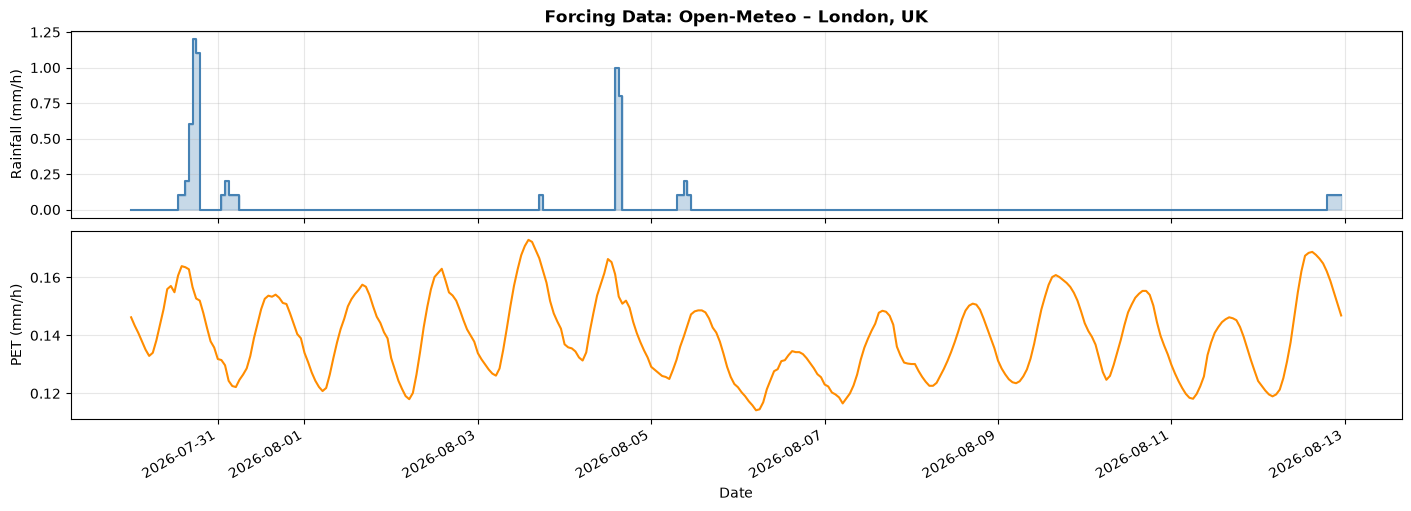

Total rainfall: 6.8 mm
Total PET:      46.9 mm


In [25]:
# ── Plot the raw forcing data ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True, constrained_layout=True)

t_idx = range(len(forcing_weather))
has_ts = 'timestamp' in forcing_weather.columns and forcing_weather['timestamp'].notna().any()
x_vals = pd.to_datetime(forcing_weather['timestamp']) if has_ts else t_idx
x_label = 'Date' if has_ts else 'Hour index'

axes[0].step(x_vals, forcing_weather['rainfall_mm_h'], where='post', color='steelblue', lw=1.5)
axes[0].fill_between(x_vals, forcing_weather['rainfall_mm_h'], step='post', alpha=0.3, color='steelblue')
axes[0].set_ylabel('Rainfall (mm/h)')
axes[0].set_title(f'Forcing Data: {forcing_label}', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, forcing_weather['pet_mm_h'], color='darkorange', lw=1.5)
axes[1].set_ylabel('PET (mm/h)')
axes[1].set_xlabel(x_label)
axes[1].grid(True, alpha=0.3)

if has_ts:
    fig.autofmt_xdate()
plt.show()
print(f'Total rainfall: {forcing_weather["rainfall_mm_h"].sum():.1f} mm')
print(f'Total PET:      {forcing_weather["pet_mm_h"].sum():.1f} mm')

In [26]:
# ── Run the full simulation (slope + grass vegetation) ────────────────────────
print('Running simulation with weather forcing + grass + 6° slope…')
profile_wx, diag_wx = run_and_collect(
    soil, column, sim_weather, forcing_weather,
    output_subdir='sec4_weather', vegetation=veg_weather,
)
print(f'Done.  {len(diag_wx)} timesteps.')

Running simulation with weather forcing + grass + 6° slope…
Vegetation: grass (rooting depth 0.30 m, PET scale 1.00)
Wrote profile output: outputs/sec4_weather/soil_moisture_profiles.csv
Wrote diagnostics output: outputs/sec4_weather/water_balance_diagnostics.csv
Wrote visualization: outputs/sec4_weather/moisture_heatmap.png
Done.  336 timesteps.


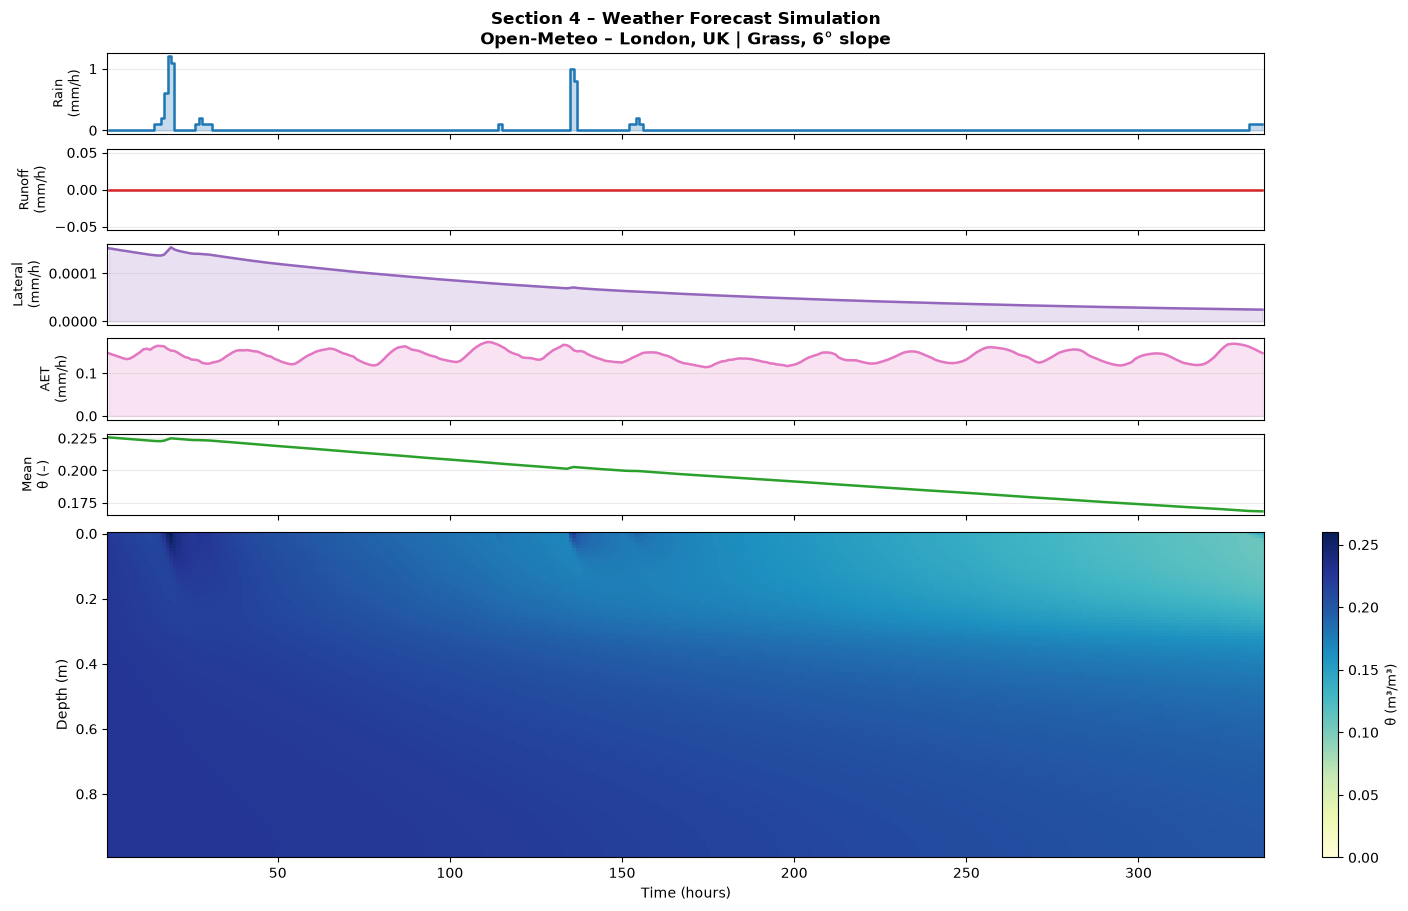

In [27]:
# ── Full water balance dashboard ──────────────────────────────────────────────
plot_water_balance(
    diag_wx, profile_wx,
    title=f'Section 4 – Weather Forecast Simulation\n{forcing_label} | Grass, 6° slope'
)

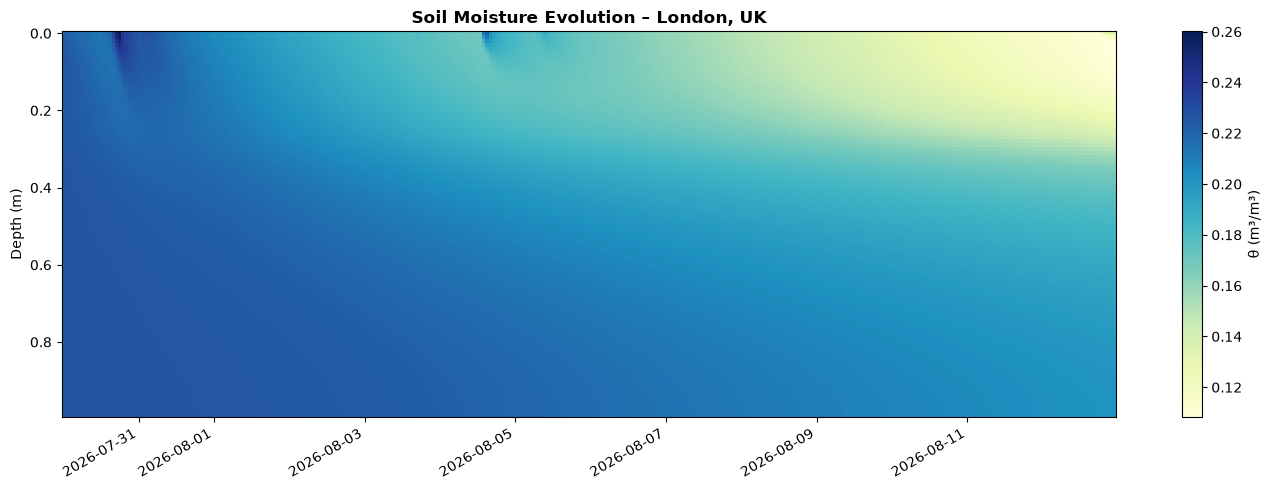

In [28]:
# ── Soil moisture heatmap with real timestamps ────────────────────────────────
if has_ts and 'timestamp' in profile_wx.columns and pd.notna(profile_wx['timestamp']).any():
    profile_wx['timestamp'] = pd.to_datetime(profile_wx['timestamp'])
    pivot_wx = (
        profile_wx
        .pivot_table(index='depth_m', columns='timestamp', values='theta', aggfunc='mean')
        .sort_index(ascending=True)
    )
    fig, ax = plt.subplots(figsize=(14, 5))
    mesh = ax.pcolormesh(
        pivot_wx.columns, pivot_wx.index, pivot_wx.values,
        shading='auto', cmap='YlGnBu',
    )
    ax.invert_yaxis()
    ax.set_ylabel('Depth (m)')
    ax.set_title(f'Soil Moisture Evolution – {SITE_NAME}', fontweight='bold')
    plt.colorbar(mesh, ax=ax, label='θ (m³/m³)')
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    plot_water_balance(diag_wx, profile_wx, title='Section 4 – Soil Moisture Heatmap')

In [29]:
# ── Final water balance summary ───────────────────────────────────────────────
print('──── Final Water Balance Summary ────')
for label, diag in [
    ('Flat (no slope, no veg)', diag_flat),
    ('6° slope, no veg',        diag_6),
    ('6° slope + woodland',     results_veg['broadleaf_woodland'][1]),
    ('6° slope + weather',      diag_wx),
]:
    rain = diag['rainfall_mm_h'].sum()
    ro   = diag['runoff_mm_h'].sum()
    lat  = diag['lateral_throughflow_mm_h'].sum()
    aet  = diag['aet_mm_h'].sum()
    dr   = diag['bottom_drainage_mm_h'].sum()
    print(f'  {label:<35}  rain={rain:5.0f} mm  runoff={ro:5.1f}  lateral={lat:5.1f}  AET={aet:5.1f}  drain={dr:5.1f}')

──── Final Water Balance Summary ────
  Flat (no slope, no veg)              rain=   65 mm  runoff=  0.0  lateral=  0.0  AET= 19.6  drain= 16.8
  6° slope, no veg                     rain=   65 mm  runoff=  0.0  lateral=  0.1  AET= 19.6  drain= 16.8
  6° slope + woodland                  rain=   65 mm  runoff=  0.0  lateral=  0.1  AET= 21.6  drain= 12.7
  6° slope + weather                   rain=    7 mm  runoff=  0.0  lateral=  0.0  AET= 46.9  drain= 17.4


---
## Summary and Key Takeaways

Through this tutorial you have:

1. **Built intuition for Richards-equation soil physics** – infiltration, wetting fronts, drainage.
2. **Seen how slope redirects water** from vertical drainage to lateral subsurface flow.
3. **Quantified the role of vegetation** in intercepting rainfall energy and extracting deep soil water through roots.
4. **Connected the model to real weather data** using the Open-Meteo API, enabling both hindcast (up to 100 days back) and forecast (16 days ahead) simulations.

### Ideas for further exploration
- **Change soil type**: try a clay soil (low K_s, high θ_s) vs. a sandy soil.
- **Longer historical runs**: set `HISTORICAL_DAYS = 100` to capture seasonal cycles.
- **Extreme events**: load a storm CSV and observe flash-runoff generation.
- **Sensitivity analysis**: vary slope angle or rooting depth and quantify impact on AET and runoff.
- **Multiple vegetation scenarios**: compare a forested catchment with a ploughed field.

### thetaFlow CLI reference
```bash
# Basic run with CSV forcing:
python simulate_soil_column.py --soil-config soil_properties_example.json --forcing-csv forcing_example.csv

# With slope and vegetation:
python simulate_soil_column.py --vegetation broadleaf_woodland

# With live weather (7 historical days + 8-day forecast):
python simulate_soil_column.py \
  --openmeteo-lat 51.5 \
  --openmeteo-lon -0.1 \
  --openmeteo-historical-days 7 \
  --vegetation grass
```